# Personal Information
Name: **Buğra Sipahioğlı**

StudentID: **14318334**

Email: [**bugra.sipahioglu@student.uva.nl**](youremail@student.uva.nl)

Submitted on: **23.03.2026**

# Data Context


# Data Description

In [5]:
# Imports
import os
import numpy as np
import pandas as pd
from tell_me_again import StoryDataset, SimilarityDataset
import json
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.probability import FreqDist

## Dataset 1: MAVEN

### Data Loading

In [2]:
# Define the core directories
PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname("."), ".."))
MAVEN_DIR_RAW = os.path.join(PROJECT_ROOT, "data", "raw", "MAVEN")

# Load the data
df_train = pd.read_json(os.path.join(MAVEN_DIR_RAW, "train.jsonl"), lines=True)
df_val = pd.read_json(os.path.join(MAVEN_DIR_RAW, "valid.jsonl"), lines=True)
df_test = pd.read_json(os.path.join(MAVEN_DIR_RAW, "test.jsonl"), lines=True)

### Analysis 1: Corpus-level Overview
We inspect corpus size (number of documents and variables per split), variable types, and missing values. We also show one example document so the structure of content, events, and negative_triggers is clear.


*MAVEN is a document-level event-detection dataset: each row is one document with title, id, and content (tokenized sentences); in train/validation each document has annotated events (with type and trigger span) and negative_triggers; the test set provides only content and candidates for trigger (and possibly type) prediction.*

In [3]:
# Analyse the shapes of train, valid, and test splits
print("\033[1;33m\nShapes of the splits:\033[0m")
for name, df in [("Train", df_train), ("Valid", df_val), ("Test", df_test)]:
    print(f"  {name}: {df.shape}")

# Print the variable types and non-null counts for all splits
print("\033[1;33m\nVariable types and non-null counts (train):\033[0m"); print(df_train.info())
print("\033[1;33m\nVariable types and non-null counts (validation):\033[0m"); print(df_val.info())
print("\033[1;33m\nVariable types and non-null counts (test):\033[0m"); print(df_test.info())

# Print the missing values per variable
print("\033[1;33m\nMissing values per variable (train):\033[0m\n" + str(df_train.isna().sum()))
print("\033[1;33m\nMissing values per variable (validation):\033[0m\n" + str(df_val.isna().sum()))
print("\033[1;33m\nMissing values per variable (test):\033[0m\n" + str(df_test.isna().sum()))

# Print one full document entity from the train split for inspection
print("\033[1;33m\nExample document from train split:\033[0m")
print(json.dumps(df_train.iloc[0].to_dict(), indent=2, ensure_ascii=False))


Shapes of the splits:
  Train: (2913, 5)
  Valid: (710, 5)
  Test: (857, 4)

Variable types and non-null counts (train):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2913 entries, 0 to 2912
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   title              2913 non-null   object
 1   id                 2913 non-null   object
 2   content            2913 non-null   object
 3   events             2913 non-null   object
 4   negative_triggers  2913 non-null   object
dtypes: object(5)
memory usage: 113.9+ KB
None

Variable types and non-null counts (validation):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 710 entries, 0 to 709
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   title              710 non-null    object
 1   id                 710 non-null    object
 2   content            710 non-null    object
 3   ev

### Analysis 2: Pre-variable-level Overview

We describe the corpus before defining model-ready variables: document-level lengths (sentences, tokens), token-count statistics (vocabulary size, hapax count), and annotation counts (events and negative triggers per document). This characterises the raw text and annotations that will later be turned into features.


*We characterised the MAVEN corpus at a pre-variable level by computing, for each document in the train and validation splits, the number of sentences, total tokens, in-document vocabulary size, number of hapax legomena, number of events, and number of negative triggers. Summary statistics and side-by-side comparison showed that train and validation have similar distributions for these quantities, with no missing values in the analysed fields. Document length (sentences and tokens) and annotation counts (events and negative triggers) are right-skewed, with a majority of short to medium documents and a long tail of longer, more event-dense documents. These statistics describe the raw corpus before defining model-ready variables and support the choice of MAVEN for supervised event detection and the assumption that train and validation are comparable for evaluation.*




Combined per-document stats (first 15 rows):


,doc_id,n_sentences,n_tokens,vocab_size,n_hapax,n_events,n_negative_triggers,split
0,8307a6b61b84d4eea42c1dd5e6e2cdba,9,352,175,125,39,117,train
1,387fe1dfe55067eb29e1fd4116d37af3,18,463,234,153,48,159,train
2,268c4763208c87ed7ebf55565c274d23,11,303,166,128,23,138,train
3,c95e68565081126b5c949117e423695a,10,309,162,114,33,114,train
4,3bec0b60c0940c5e46ee2cfc9504df92,10,213,133,96,23,85,train
5,39c2db9e18cd4a02b9aa8c1a3c58aab7,13,267,145,107,33,89,train
6,c1ae08941a115c7d45e205724e5aa3be,39,1215,472,334,75,468,train
7,ef451445d348d837669fbab71d1db3a2,12,295,180,142,32,118,train
8,045be42474c6c6225401d4b8cc03fe5e,8,195,105,75,23,76,train
9,eeb1b3357c409a5f55f45158ce2a62e5,7,118,84,68,15,40,train



Summary (train vs valid):


,train_mean,train_std,valid_mean,valid_std
n_sentences,11.133196,5.468577,11.326761,6.460926
n_tokens,285.680055,152.267703,288.107042,172.912803
vocab_size,152.967044,64.632639,153.097183,69.264933
n_hapax,112.732578,47.421373,112.452113,49.685639
n_events,25.230347,16.089320,24.966197,16.614232
n_negative_triggers,111.222794,61.776284,112.252113,69.998709



Describe by split:


n_sentences                                                  n_tokens  \
            count       mean       std  min  25%   50%   75%   max    count   
split                                                                         
train      2913.0  11.133196  5.468577  6.0  7.0  10.0  13.0  57.0   2913.0   
valid       710.0  11.326761  6.460926  6.0  7.0   9.0  14.0  75.0    710.0   

                   ... n_events        n_negative_triggers              \
             mean  ...      75%    max               count        mean   
split              ...                                                   
train  285.680055  ...     32.0  122.0              2913.0  111.222794   
valid  288.107042  ...     32.0  128.0               710.0  112.252113   

                                                   
             std   min   25%   50%     75%    max  
split                                              
train  61.776284  22.0  69.0  96.0  137.00  845.0  
valid  69.998709  23.0  69.0  93.5  136.75  777.0  

[2 rows x 48 columns]

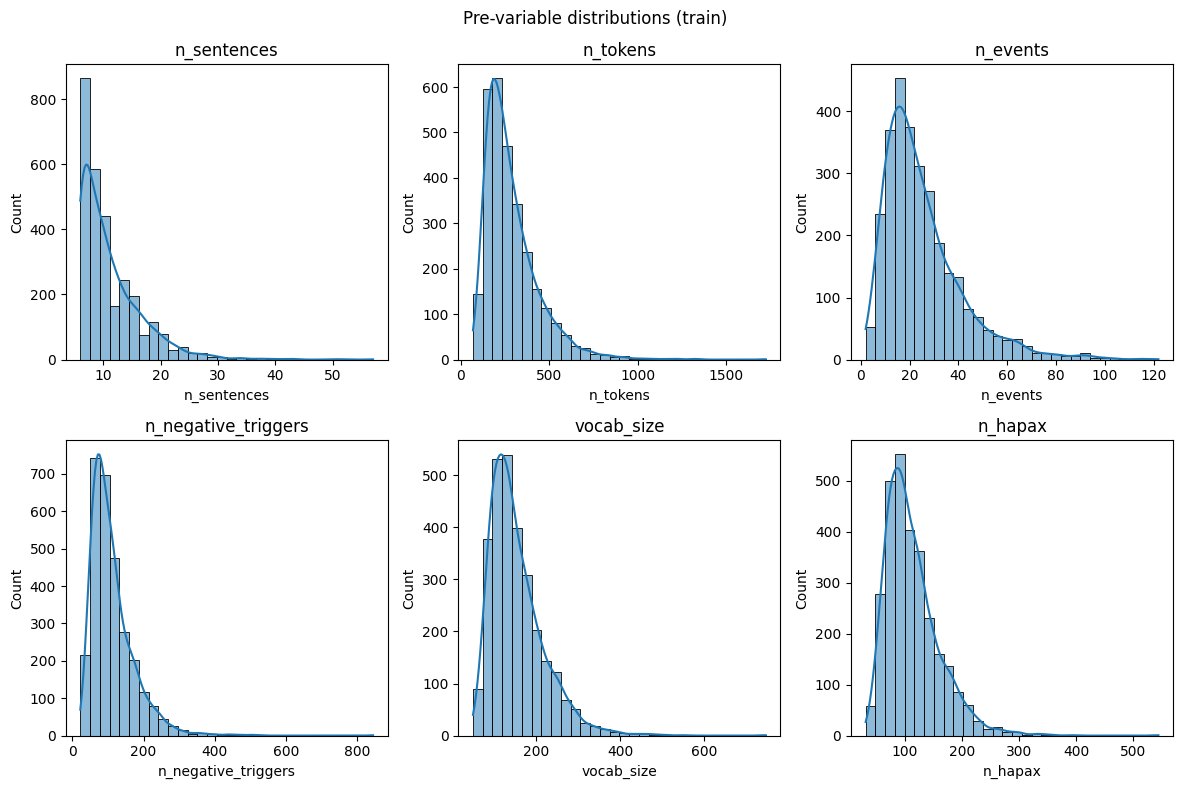

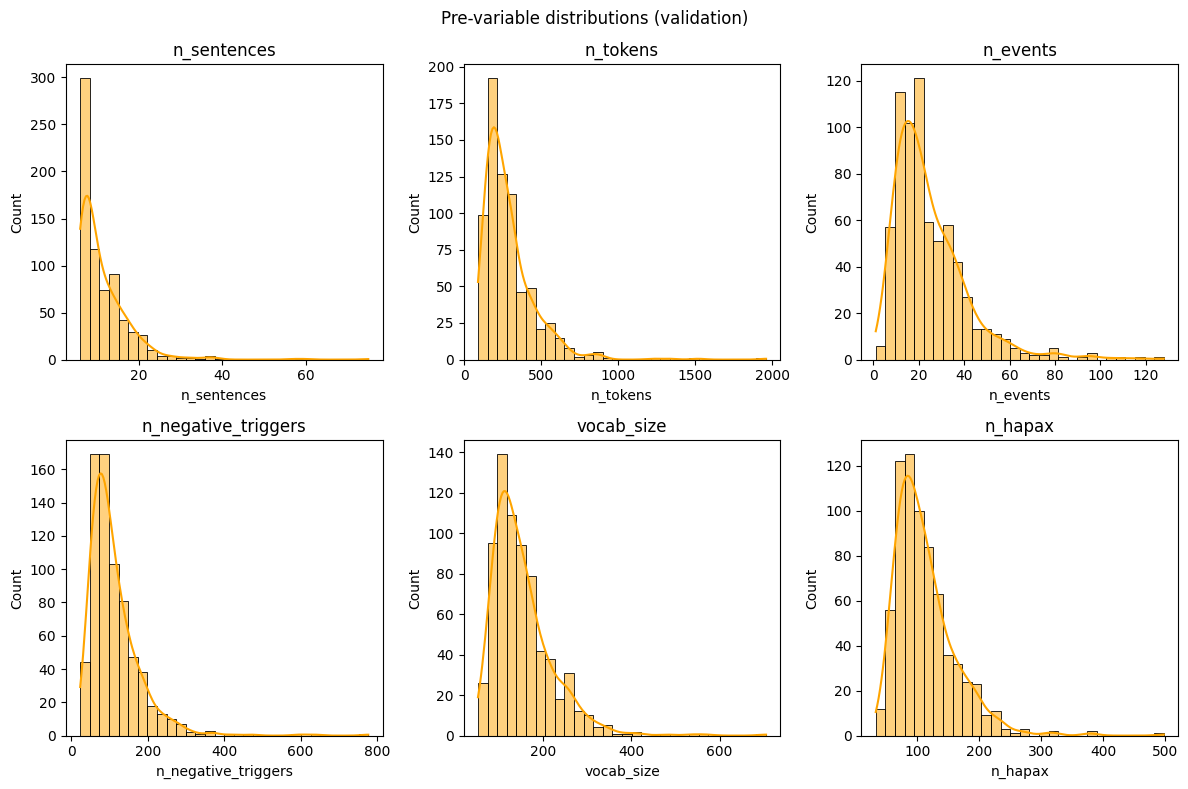

In [9]:
def prevariable_stats(df):
    """
    Computes per-document statistics from a MAVEN event detection dataset dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe in MAVEN format: each row is a document with at least a `content` 
        (list of sentence dicts with "tokens"), and optionally columns 'events' and 
        'negative_triggers'.

    Returns
    -------
    pd.DataFrame
        Dataframe with one row per document containing the following columns:
            - n_sentences: Number of sentences in document
            - n_tokens: Number of tokens in document
            - vocab_size: Number of unique tokens (vocabulary size) in document
            - n_hapax: Number of tokens that occur only once (hapax legomena) in document
            - n_events: Number of events in document (if present)
            - n_negative_triggers: Number of negative triggers in document (if present)
    """
    # get the num of sentences, tokens, events, and negative triggers
    n_sentences = df["content"].map(len)
    n_tokens = df["content"].map(lambda c: sum(len(s["tokens"]) for s in c))
    n_events = df["events"].map(len) if "events" in df.columns else None
    n_neg = df["negative_triggers"].map(len) if "negative_triggers" in df.columns else None

    # For each document, extract tokens and compute vocabulary size and hapax count.
    def vocab_and_hapax(content_list):
        tokens = [t for sent in content_list for t in sent["tokens"]]
        fdist = FreqDist(tokens)
        return len(fdist), len(fdist.hapaxes())

    # Apply the function to each document in the dataframe
    vocab_size, n_hapax = zip(*df["content"].map(vocab_and_hapax))

    # Create a dataframe with the computed statistics
    out = pd.DataFrame({"n_sentences": n_sentences, "n_tokens": n_tokens, "vocab_size": vocab_size, "n_hapax": n_hapax})
    if n_events is not None:
        out["n_events"] = n_events
    if n_neg is not None:
        out["n_negative_triggers"] = n_neg
    return out

# Compute per-document stats
stats_train = prevariable_stats(df_train)
stats_val = prevariable_stats(df_val)

# One combined dataframe with split and doc_id
stats_train_labeled = stats_train.assign(split="train")
stats_val_labeled = stats_val.assign(split="valid")
stats_all = pd.concat([stats_train_labeled, stats_val_labeled], ignore_index=True)
stats_all.insert(0, "doc_id", np.concatenate([df_train["id"].values, df_val["id"].values]))

# Summary dataframe: train vs valid side by side (mean, std)
summary_side_by_side = pd.DataFrame({
    "train_mean": stats_train.mean(),
    "train_std": stats_train.std(),
    "valid_mean": stats_val.mean(),
    "valid_std": stats_val.std(),
})

# Print all the stats
print("\033[1;33m\nCombined per-document stats (first 15 rows):\033[0m"); display(stats_all.head(15))
print("\033[1;33m\nSummary (train vs valid):\033[0m"); display(summary_side_by_side)
print("\033[1;33m\nDescribe by split:\033[0m"); display(stats_all.groupby("split").describe())


# Define the columns to plot histograms
cols = ["n_sentences", "n_tokens", "n_events", "n_negative_triggers", "vocab_size", "n_hapax"]

# Plot for train
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, col in zip(axes.flat, cols):
    if col in stats_train.columns:
        sns.histplot(stats_train[col], kde=True, ax=ax, bins=30)
        ax.set_title(col)
    else:
        ax.axis('off')
plt.suptitle("Pre-variable distributions (train)", fontsize=12)
plt.tight_layout()
plt.show()

# Plot for validation
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, col in zip(axes.flat, cols):
    if col in stats_val.columns:
        sns.histplot(stats_val[col], kde=True, ax=ax, bins=30, color='orange')
        ax.set_title(col)
    else:
        ax.axis('off')
plt.suptitle("Pre-variable distributions (validation)", fontsize=12)
plt.tight_layout()
plt.show()

### Analysis 3: Univariate-level Overview

We look at one variable at a time: event type (and type_id) distribution across the corpus, trigger-word frequency, and the class balance between event triggers and negative triggers. This yields priors for event-type classification and for binary trigger detection, and shows the long-tail nature of the event ontology.


TRAIN
Event type (categorical) — value counts (top 20):
Causation             2653
Process_start         2562
Attack                2535
Hostile_encounter     2411
Catastrophe           2172
Motion                2109
Competition           2032
Killing               1487
Process_end           1374
Social_event          1369
Conquering            1353
Statement             1350
Self_motion           1241
Arriving              1217
Destroying            1136
Coming_to_be          1093
Bodily_harm           1007
Death                  963
Creating               924
Military_operation     920
Name: count, dtype: int64

Event type_id (numeric) — describe:
count    73496.000000
mean        51.593787
std         40.285666
min          1.000000
25%         19.000000
50%         40.000000
75%         82.000000
max        168.000000
dtype: float64

Prior P(type) — top 20:
Causation             0.036097
Process_start         0.034859
Attack                0.034492
Hostile_encounter     0.032805


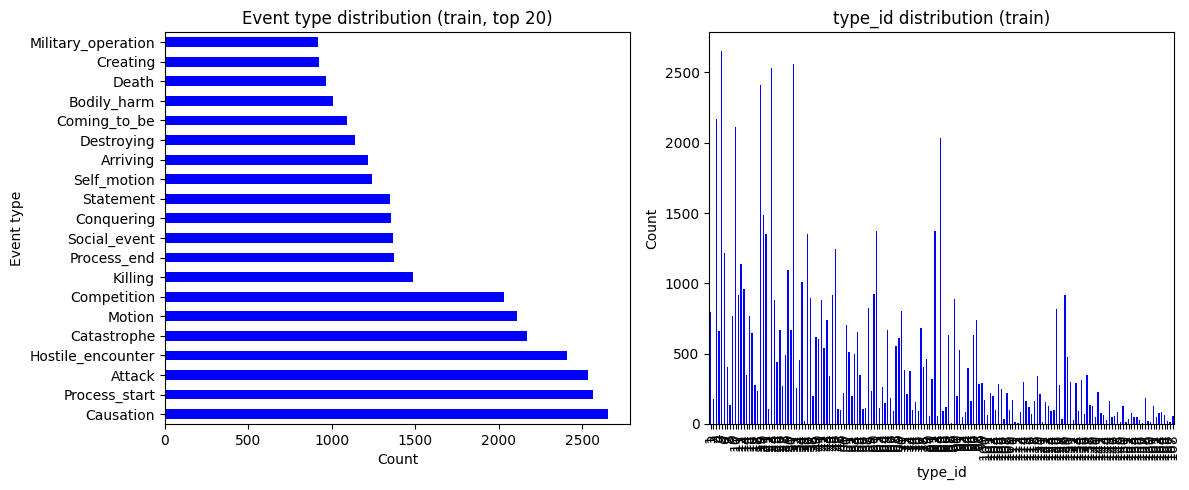


VALID
Event type (categorical) — value counts (top 20):
Hostile_encounter                      646
Causation                              644
Process_start                          629
Competition                            593
Catastrophe                            577
Attack                                 524
Motion                                 424
Killing                                352
Process_end                            331
Statement                              327
Self_motion                            324
Social_event                           320
Conquering                             308
Arriving                               304
Coming_to_be                           294
Destroying                             261
Damaging                               239
Becoming                               233
Cause_change_of_position_on_a_scale    233
Bodily_harm                            228
Name: count, dtype: int64

Event type_id (numeric) — describe:
count    17726.00000

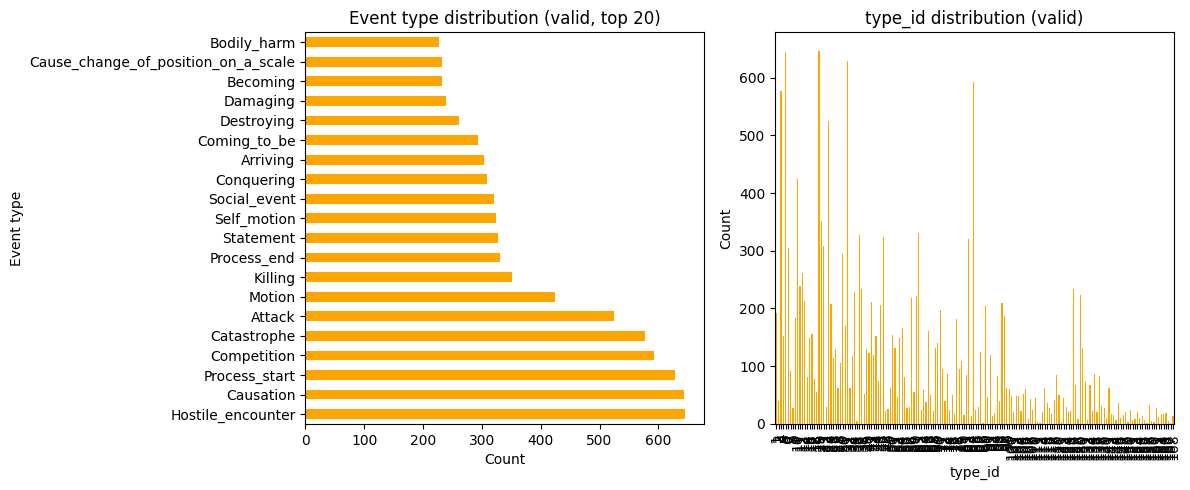

In [23]:
def get_event_type_series(df):
    """Collect (type, type_id) for every event in df. Returns (type_series, type_id_series)."""
    all_types = []
    all_type_ids = []
    for _, row in df.iterrows():
        for ev in row["events"]:
            all_types.append(ev["type"])
            all_type_ids.append(ev["type_id"])
    return pd.Series(all_types), pd.Series(all_type_ids)

def get_trigger_balance(df):
    """Return (n_positive, n_negative, total) trigger spans."""
    n_positive = sum(len(ev.get("mention", [])) for _, row in df.iterrows() for ev in row["events"])
    n_negative = df["negative_triggers"].map(len).sum()
    total = n_positive + n_negative
    return n_positive, n_negative, total

def get_trigger_word_counts(df):
    """Return Series of trigger-word value counts."""
    words = []
    for _, row in df.iterrows():
        for ev in row["events"]:
            for m in ev.get("mention", []):
                w = m.get("trigger_word")
                if w is not None:
                    words.append(w)
    return pd.Series(words).value_counts()

def run_univariate_for_split(df, split_name, n_top=20, plot=True):
    """Run full univariate analysis for one split (train or valid)."""
    type_series, type_id_series = get_event_type_series(df)
    n_events = len(type_series)

    print(f"\033[1;33m\n{split_name.upper()}\033[0m")
    print(f"\033[1mEvent type (categorical) — value counts (top {n_top}):\033[0m")
    print(type_series.value_counts().head(n_top))
    print("\033[1m\nEvent type_id (numeric) — describe:\033[0m")
    print(type_id_series.describe())
    prior_top = type_series.value_counts().head(n_top) / n_events
    print(f"\033[1m\nPrior P(type) — top {n_top}:\033[0m")
    print(prior_top)

    n_pos, n_neg, total = get_trigger_balance(df)
    print(f"\033[1m\nTrigger vs negative:\033[0m \n - positive: {n_pos}, \n - negative: {n_neg}, \n - total: {total}")
    print(f"\033[1mPriors: \033[0m \n - P(positive) = {n_pos / total:.4f}, \n - P(negative) = {n_neg / total:.4f}")
    print("\033[1m\nTop 20 trigger words:\033[0m")
    print(get_trigger_word_counts(df).head(20))

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        # Set color: train = blue, val = orange
        color = "blue" if split_name.lower() == "train" else "orange"
        type_series.value_counts().head(n_top).plot(kind="barh", ax=axes[0], color=color)
        axes[0].set_xlabel("Count")
        axes[0].set_ylabel("Event type")
        axes[0].set_title(f"Event type distribution ({split_name}, top {n_top})")
        type_id_series.value_counts().sort_index().plot(kind="bar", ax=axes[1], color=color)
        axes[1].set_xlabel("type_id")
        axes[1].set_ylabel("Count")
        axes[1].set_title(f"type_id distribution ({split_name})")
        plt.tight_layout()
        plt.show()

# Run for both splits
for name, data in [("train", df_train), ("valid", df_val)]:
    run_univariate_for_split(data, name, n_top=20, plot=True)

### Analysis 4: Baseline

We derive trivial baseline scores from the corpus priors (trigger vs negative and event-type distribution) so we have a lower bound any real model must beat. We then briefly reference the MAVEN benchmark (Wang et al., 2020): BERT+CRF reaches 67.8 F1 on MAVEN trigger classification; we use this model as our event extractor for the Tell Me Again pipeline and do not aim to improve MAVEN event detection itself.

*We use the MAVEN dataset for supervised event detection. From the training set, we computed trivial baselines: always predicting the negative class yields accuracy equal to the proportion of negative triggers (P(negative)), while always predicting the majority event type yields accuracy equal to the prior of the most frequent type. Any meaningful event detector must exceed these prior baselines. As the extractor, we rely on the BERT+CRF model reported by Wang et al. (2020), which achieves 67.8 F1 on MAVEN trigger classification. We do not aim to improve event detection on MAVEN but instead use it as an off-the-shelf component for our narrative similarity pipeline on the Tell Me Again dataset.*



In [ ]:
# Calculate priors for trigger vs negative trigger detection
n_pos, n_neg, total = get_trigger_balance(df_train)
p_neg = n_neg / total
p_pos = n_pos / total

# Calculate priors for event type classification
type_series, _ = get_event_type_series(df_train)
n_events = len(type_series)
majority_type = type_series.value_counts().index[0]
majority_count = type_series.value_counts().iloc[0]
p_majority_type = majority_count / n_events

print(f"\033[1;33m\nPrior baselines (train)\033[0m")
print(f"\033[1m  • Trigger vs negative:\033[0m \n - P(negative) = {p_neg:.4f} → 'always predict negative' accuracy = {p_neg:.4f}")
print(f"\033[1m  • Event type:\033[0m \n - majority type = '{majority_type}' (P = {p_majority_type:.4f}) → 'always predict majority' accuracy = {p_majority_type:.4f}")

# Print a summary table of the baseline accuracies
print("\033[1;33m\nBaseline accuracies from corpus priors (train set)\033[0m")
baseline_summary = pd.DataFrame({
    "Baseline": [
        "Always negative (trigger detection)",
        "Majority event type (type classification)",
    ],
    "Train accuracy": [p_neg, p_majority_type],
})
display(baseline_summary)

# 2) MAVEN paper benchmark (for methodology / related work)
print("\nMAVEN benchmark (Wang et al., 2020, Table 5 — trigger classification on MAVEN test):")
print("  • BERT+CRF: P=65.0, R=70.9, F1=67.8 (best in paper)")
print("  • We use BERT+CRF as the event extractor; our thesis focus is on Tell Me Again, not improving MAVEN ED.")


Prior baselines (train)
  • Trigger vs negative: 
 - P(negative) = 0.8060 → 'always predict negative' accuracy = 0.8060
  • Event type: 
 - majority type = 'Causation' (P = 0.0361) → 'always predict majority' accuracy = 0.0361

Baseline accuracies from corpus priors (train set)


,Baseline,Train accuracy
0,Always negative (trigger detection),0.805980
1,Majority event type (type classification),0.036097



MAVEN benchmark (Wang et al., 2020, Table 5 — trigger classification on MAVEN test):
  • BERT+CRF: P=65.0, R=70.9, F1=67.8 (best in paper)
  • We use BERT+CRF as the event extractor; our thesis focus is on Tell Me Again, not improving MAVEN ED.
